En este ejemplo queremos resolver la pregunta ¿Podemos predecir el precio de una nueva casa a partir de alguna de sus características?


Para ello se usa el conjunto de datos de vivienda de Boston de Scikit-learn, que proporciona mediciones registradas
de 13 atributos de los mercados de la vivienda de Boston, así como el precio medio de la vivienda.
[Enlace](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/?C=N;O=D)

Una vez cargado el conjunto de datos (506 instancias), la descripción del mismo puede obtenerse fácilmente imprimiendo el campo **DESCR**.
```
print(boston.DESCR)
```

Los las características (x)
y el objetivo (y) se almacenan en otros campos del conjunto de datos:

```
X_boston , y_boston = boston.data , boston.target
```



In [132]:
import pandas as pd
import seaborn as sns
df_boston = pd.read_csv('HousingData.csv')


In [133]:
print(df_boston.head())
print(df_boston.describe())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695    6.284634   
std      8.720192   23.388876    6.835896    0.255340    0.115878    0.702617   
min      0.006320    0.000000    0.460000    

En primer lugar, consideramos la tarea de predecir el valor medio de la vivienda en el área de Boston utilizando como variable uno de los atributos, por ejemplo, *LSTAT*, definido como la *"proporción de  personas de estatus más bajo en la población"*.

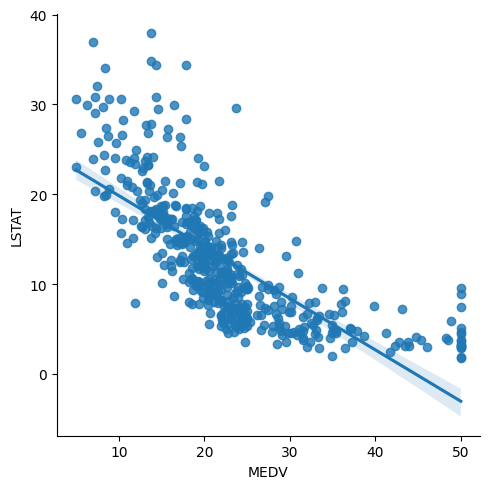

In [134]:
sns.lmplot(data = df_boston, x = "MEDV", y = "LSTAT",  order = 1)

Se puede observar ver claramente que la relación entre el precio y LSTAT es no lineal, ya que la línea recta ofrece un ajuste pobre.

Se puede probar fácilmente si se puede obtener un mejor ajuste
puede obtenerse incluyendo términos de orden superior. Por ejemplo, un modelo cuadrático ($order = 2$):

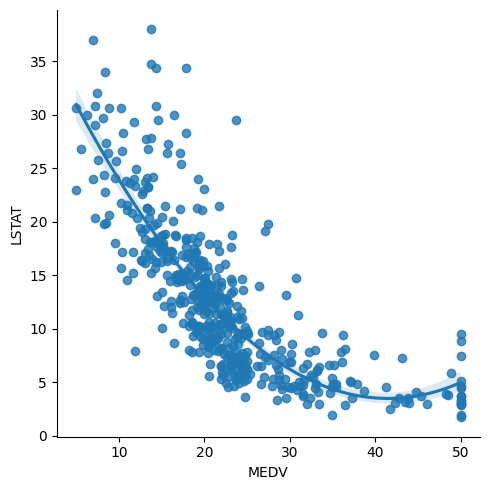

In [135]:
sns.lmplot(data = df_boston, x = "MEDV", y = "LSTAT",  order = 2)

Podemos estudiar la relación entre varias variables de un conjunto de datos mediante
utilizando las funciones **corr** y **heatmap** que permiten calcular una matriz de correlación
para un conjunto de datos y dibujar un mapa de calor con los valores de correlación.

El mapa de calor
es una imagen matricial que ayuda a interpretar las correlaciones entre las variables.

<Axes: >

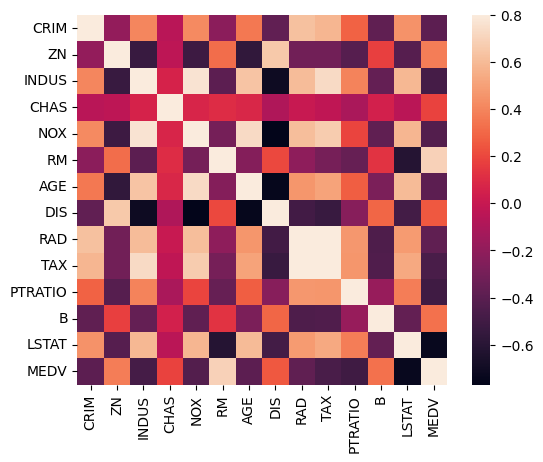

In [136]:
corrmat = df_boston.corr()
sns.heatmap( corrmat , vmax = .8, square = True)

Podemos seleccionar aquellas variables más correlacionadas con el precio o las que consideremos más interesantes.

<Axes: >

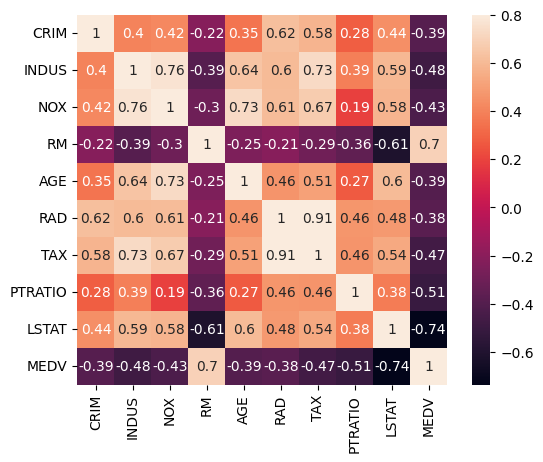

In [137]:
df_boston_red = df_boston[["CRIM", "INDUS", "NOX", "RM", "AGE", "RAD", "TAX", "PTRATIO", "LSTAT", "MEDV"]]
corrmat_red = df_boston_red.corr()
sns.heatmap( corrmat_red , vmax = .8, square = True, annot=True)

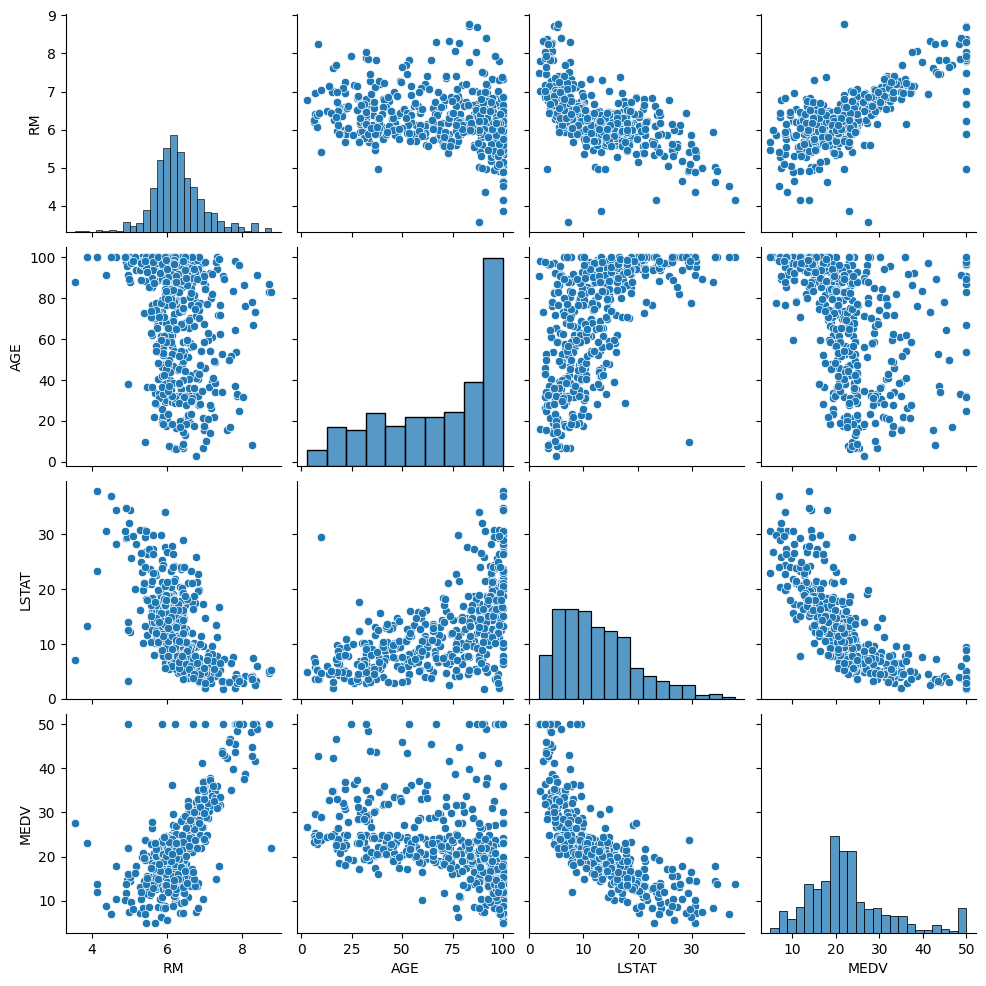

In [138]:
#sns.pairplot(df_boston_red)
sns.pairplot(df_boston_red[["RM", "AGE", "LSTAT", "MEDV"]])

Para evaluar el poder de predicción del modelo con nuevas muestras:

1. dividimos en conjunto de entrenamiento y test.



In [139]:
# Sustituimos NaN por la media de la columna
df_boston_red = df_boston_red.fillna(df_boston_red.mean())

train_size = int(df_boston_red.shape[0]/2)
X_train = df_boston_red.drop("MEDV", axis=1)[:train_size]
X_test = df_boston_red.drop("MEDV", axis=1)[train_size:]
y_train = df_boston_red["MEDV"][:train_size]
y_test = df_boston_red["MEDV"][train_size:]
print ("Training and testing set sizes",X_train.shape , X_test.shape)

Training and testing set sizes (253, 9) (253, 9)


2. calculamos los coeficientes de la regresión lineal

In [140]:
from sklearn. linear_model import LinearRegression
regr = LinearRegression()
regr.fit(X_train , y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
print ("Coeff and intercept:", regr.coef_ , regr.intercept_)


Coeff and intercept: [ 0.03419718  0.04604638  1.09827501  9.50064476 -0.02713674  0.01109589
 -0.01276263 -0.67291625 -0.11718956] -17.641816889572933


3. ejecutamos la predicción sobre los datos de test

In [142]:
y_pred = regr.predict(X_test)


4. evaluamos el modelo mediante el uso del coeficiente $R^2$. También podemos calcular también el **MSE**.

In [143]:
from sklearn import metrics
print ("MSE:", metrics.mean_squared_error(y_pred , y_test))
print ("R^2:", metrics.r2_score(y_pred , y_test))
print ("var:", y_pred.var(), y_test.var())

MSE: 58.90904870454966
R^2: 0.35698506375341843
var: 91.61381079017328 93.65688844971454


Podemos ver que todos los coeficientes obtenidos son diferentes de cero, lo que significa que no se descarta ninguna variable.

A continuación, intentamos construir un modelo disperso para predecir el precio utilizando los factores más importantes y descartando los no informativos. Para ello
podemos crear un regresor **Lasso**, forzando los coeficientes cero.

In [144]:
from sklearn.linear_model import Lasso
regr_lasso = Lasso(alpha = .3)
regr_lasso.fit( X_train , y_train)
y_pred = regr_lasso.predict(X_test)
print ("MSE:", metrics.mean_squared_error(y_pred , y_test))
print ("R^2:", metrics.r2_score(y_pred , y_test))
print ("var:", y_pred.var(), y_test.var())

MSE: 52.64464488749775
R^2: 0.39943406400106196
var: 87.65839307874238 93.65688844971454


In [145]:
print ("Coeff and intercept:", regr_lasso.coef_ , regr_lasso.intercept_)

Coeff and intercept: [ 0.          0.02007712  0.          8.1916391  -0.0181153   0.
 -0.01208389 -0.67084494 -0.20463809] -8.305088532648572


De aquí podemos obtener una serie de variables y su relativa contribución a la predicción.

In [146]:
import numpy as np
ind = np.argsort(np. abs(regr_lasso.coef_))
print ("(Ordered variable ( from less to more important):)")
print (df_boston_red.drop("MEDV", axis=1).columns[ind])

(Ordered variable ( from less to more important):)
Index(['CRIM', 'NOX', 'RAD', 'TAX', 'AGE', 'INDUS', 'LSTAT', 'PTRATIO', 'RM'], dtype='object')


Para evaluar la predicción, podría ser interesante visualizar las respuestas objetivo
y las respuestas predichas en un gráfico de dispersión, como se hace en el siguiente código:

Text(0, 0.5, 'Predicted price ($1000s)')

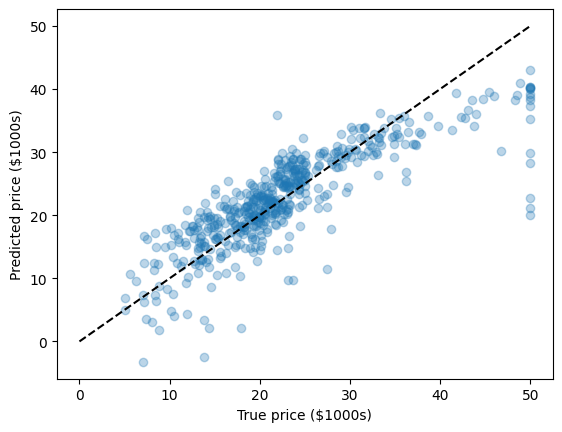

In [147]:
clf = LinearRegression()
clf.fit(df_boston_red.drop("MEDV", axis=1) , df_boston_red["MEDV"])
predicted = clf.predict(df_boston_red.drop("MEDV", axis=1))

import matplotlib.pyplot as plt

plt.scatter(df_boston_red["MEDV"] , predicted , alpha = 0.3)
plt.plot([0, 50], [0, 50], "--k")
plt.axis("tight")
plt.xlabel("True price ($1000s)")
plt.ylabel("Predicted price ($1000s)")

También hay otras estrategias para la selección de características. Por ejemplo, podemos seleccionar
las $k=5$ mejores características, según las $k$ puntuaciones más altas, utilizando la función
$SelectKBest$ de Scikit-learn:

In [148]:
import sklearn. feature_selection as fs
selector = fs.SelectKBest( score_func = fs.f_regression , k = 5)
X_best = selector.fit_transform( X_train , y_train)
selector.fit( X_train , y_train)
print ("Selected features:",zip(selector.get_support() , df_boston_red.drop("MEDV", axis=1).columns))

Selected features: <zip object at 0x000001E235B95400>


In [149]:
df_boston_red.drop("MEDV", axis=1).columns[selector.get_support(indices=True)].tolist()

['INDUS', 'RM', 'AGE', 'PTRATIO', 'LSTAT']